# Orbital Data Center: Levelized Cost of Compute (LCOC) Model — v3

**Project:** Feasibility study of whether passive radiative cooling and falling launch costs can make an Orbital Data Center (ODC) cost-competitive with a Terrestrial Data Center (TDC) for AI training workloads.

**Method:** First-principles sizing of PV array and radiator → mass and cost budget → LCOC via Nøland et al. (2024) Eq. 1.

**Model structure (v3, locked initial values):**
- **One** baseline ODC scenario in 2026 — all initial parameter values are now fixed at the spreadsheet values (no high/low scenarios on starting values).
- **One** terrestrial DC scenario for comparison (Nøland et al. baseline).
- **Uncertainty enters only through the learning rate** — three scenarios (Optimistic / Baseline / Pessimistic) that govern how fast each cost component declines (or how fast efficiencies grow). This produces the shaded uncertainty bands on time-series plots.

**Notebook outline:**
1. Constants and locked architectural assumptions
2. Baseline parameter tables (with sources)
3. Learning rate scenarios (lower bound / baseline / upper bound)
4. Physical sizing (PV, radiator, mass)
5. LCOC calculation at year 0 (2026)
6. Terrestrial DC baseline
7. Time projection 2026–2045 across learning rate scenarios
8. Visualizations (LCOC vs time, tornado, LCOC vs launch cost)
9. Summary

## 1. Constants and locked architectural assumptions

**Locked architecture (no variation across scenarios):**
- 100 MW compute payload, training workload, 100% utilization
- MEO at 15,000 km altitude (no eclipse, moderate radiation environment)
- 15-year ODC lifespan, 5-year IT refresh interval (refreshes at year 5 and year 10)
- PV and radiator are one-time launches at year 0 (no refresh)
- Two angled radiator arms at 45° from vertical, two-sided emission
- Triple-junction GaAs PV cells
- **No OPEX, no structural mass overhead**
- Cooling only the compute module (PV thermally isolated from radiator network)
- Chip temperature 85 °C with a 5 °C chip-to-radiator drop → radiator at 80 °C
- One side of the radiator arm always sees the sun at 45°
- No radiator coating degradation (no UV / AO / dust accounting)
- No disposal / decommissioning costs
- No temperature gradient across the radiator (single T_rad everywhere)
- Data drop cost itself negligible 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from dataclasses import dataclass, replace
from typing import Dict, List
import warnings
warnings.filterwarnings('ignore')

# ----- Physical constants (from spreadsheet "Earth Effective Temp" source) ----
SIGMA        = 5.67e-8            # Stefan-Boltzmann [W m^-2 K^-4]
I_SUN        = 1361               # Solar constant [W m^-2]   (NASA/SORCE TSI)
T_EARTH_EFF  = 254.15             # Earth effective radiating temp [K] (-19 C)
EARTH_ALBEDO = 0.306              # Earth bond albedo

# ----- Architecture constants ------------------------------------------------
Q_COMPUTE          = 100e6                       # 100 MW compute heat load [W]
LIFETIME_YR        = 15
REFRESH_INTERVAL   = 5                           # IT refresh every 5 yrs
HOURS_PER_YEAR     = 8765.8
SECONDS_PER_YEAR   = HOURS_PER_YEAR * 3600
ORBITAL_ALT_KM     = 15_000                      # MEO (Claudio's CF work)

## 2. Baseline ODC parameters (with sources)

All initial values are locked at the spreadsheet values. The "Learning" column indicates whether the parameter evolves over time under a learning rate (see Section 3) or stays constant for the full 15-year mission.

### 2a. Learning parameters (evolve year-over-year)

These are the cost and efficiency parameters that the learning rate scenarios act on.

| Parameter | Symbol | Value (2026) | Units | Learning | Source |
|---|---|---|---|---|---|
| Compute Efficiency | γ | **6.0** | PFLOPS/kW | ✓ | LCOC Paper (Nøland et al. 2024) |
| Launch Cost | — | **1,500** | $/kg | ✓ | Cost for Space Launch (Falcon Heavy / Starship class) |
| PV BOL Efficiency | η_BOL | **0.32** | — | ✓ | NASA Space PV (triple-junction GaAs) |
| PV Areal Cost | — | **33,000** | $/m² | ✓ | Alibaba space PV pricing (50% wholesale discount applied) |
| Radiator Areal Cost | — | **600** | $/m² | ✓ | BaSO₄ paint: $/kg × kg/m² (1 mm thickness) + Aluminium: $20-30/m²|
| IT Cost Density | — | **23,000,000** | $/MW | ✓ | DC rack pricing (DC Rack 3 & 4 sources) |

### 2b. Fixed parameters (constant over the mission)

These do not evolve in time — either physical constants of the architecture or properties that the project treats as locked.

| Parameter | Symbol | Value | Units | Source |
|---|---|---|---|---|
| PV Derating | — | 0.85 | — | NREL PVWatts Calculator |
| PV Areal Density | — | 1.76 | kg/m² | PV GaAs Triple-Junction datasheet |
| Radiator Areal Density | — | 4.5 | kg/m² | BaSO₄ density at 1 mm thickness |
| IT Mass Density | — | 55,000 | kg/MW | DC Rack & DC Rack 2 sources |
| PV View Factor (radiator → PV) | F_PV | 0.617 | — | PV view factor analysis |
| PV Temperature | T_PV | 80 | °C | PV operating temp (typical without active cooling) |
| Radiator Solar Absorptance | α_solar | 0.05 | — | Fan et al. 2025 (Adv. Mater.) — BaSO₄ class coating |
| Radiator IR Emissivity / Absorptance | α_IR | 0.95 | — | Fan et al. 2025 (Adv. Mater.) |
| Discount Rate | r | 0.10 | — | Nøland et al. 2024 LCOC paper baseline |
| Earth View Factor (radiator → Earth) | F_⊕ | 0.10 | — | Claudio's view factor work (geometric, 15,000 km altitude) |
| Radiator Temperature | T_rad | 80 | °C | li2024 chips (T_chip = 85 °C, 5 °C drop) |
| Radiator Arm Angle | θ | 45 | ° from vertical | locked architecture |
| PV IR Emissivity (backside) | ε_PV,back | 0.84 | — | PV GaAs Triple-Junction datasheet |
| Data Drop Mass | — | 1,000 | kg/drop | locked architecture |
| Data Drop Rate | — | 2 | drops/yr | locked architecture |
| ODC Lifespan | n | 15 | yrs | locked architecture |
| IT Compute Refresh Interval | — | 5 | yrs | locked architecture (refreshes at yr 5, 10) |
| ODC Compute Rating | — | 100 | MW | locked architecture |
| Solar Constant | I_⊙ | 1,361 | W/m² | Earth Effective Temp source (NASA TSI) |
| Orbital Altitude | — | 15,000 | km | Claudio's CF work (MEO) |
| Earth Albedo | α_⊕ | 0.306 | — | Earth Effective Temp source |
| Earth Effective Rad Temperature | T_⊕ | −19 | °C (254.15 K) | Earth Effective Temp source |

### 2c. Other assumptions (qualitative)

- No OPEX
- No structural mass overhead
- No eclipse in MEO
- 100% power conditioning efficiency
- Double-sided radiator emission
- Triple-junction GaAs PV cells (NASA Space PV)
- No PV or radiator refresh — only IT refreshes
- Chip temperature 85 °C, 5 °C chip-to-radiator drop (li2024 chips)
- One side of radiator arm always sees sun at 45°
- Cooling only compute module (PV thermally isolated)
- 100% utilization, no downtime
- Single TDC scenario (no optimistic / pessimistic TDC variants)
- No radiator coating degradation (no UV exposure, AO erosion, or space-dust accounting)
- No disposal / decommissioning of ODC or launch vehicles
- No temperature gradient across the radiator (single T_rad)
- Data drop cost negligible (only the launch cost of the return mass counts)

In [ ]:
@dataclass
class Scenario:
    name: str
    # Compute
    gamma_PFLOPS_per_kW: float
    # Radiator
    eps_IR: float; alpha_solar_rad: float
    F_earth: float; F_PV: float
    T_rad_C: float; T_chip_C: float; arm_angle_deg: float
    rad_areal_mass: float; rad_areal_cost: float
    # PV
    pv_eff_BOL: float; pv_derating: float
    T_PV_C: float; eps_PV_back: float
    pv_areal_mass: float; pv_areal_cost: float
    # Compute payload
    it_mass_density: float; it_cost_per_MW: float
    # Launch & data
    launch_cost_per_kg: float
    data_mass_per_drop: float; data_drops_per_year: float; data_fixed_cost: float
    # Financial
    discount_rate: float


# -----------------------------------------------------------------------------
# BASELINE (2026 initial values, locked per spreadsheet)
# -----------------------------------------------------------------------------
BASELINE = Scenario(
    name                = 'Baseline 2026',
    # ---- Learning parameters --------------------------------------------------
    gamma_PFLOPS_per_kW = 6.0,            # PFLOPS/kW   (LCOC Paper)
    launch_cost_per_kg  = 1_500.0,        # $/kg        (Cost for Space Launch)
    pv_eff_BOL          = 0.32,           # -           (NASA Space PV)
    pv_areal_cost       = 33_000.0,       # $/m^2       (Alibaba @ 50% wholesale)
    rad_areal_cost      = 600.0,          # $/m^2       (BaSO4 paint)
    it_cost_per_MW      = 23e6,           # $/MW        (DC Rack 3 & 4)
    # ---- Fixed parameters -----------------------------------------------------
    pv_derating         = 0.85,           # NREL PVWatts
    pv_areal_mass       = 1.76,           # kg/m^2      (PV GaAs TJ datasheet)
    rad_areal_mass      = 4.5,            # kg/m^2      (BaSO4 1 mm)
    it_mass_density     = 55_000.0,       # kg/MW       (DC Rack & DC Rack 2)
    F_PV                = 0.617,          # PV view factor (radiator <-> PV)
    T_PV_C              = 80.0,           # PV operating temp
    alpha_solar_rad     = 0.05,           # Fan et al. 2025
    eps_IR              = 0.95,           # Fan et al. 2025
    discount_rate       = 0.10,           # Noland 2024
    F_earth             = 0.10,           # Claudio's view factor work
    T_rad_C             = 80.0,           # li2024 chips
    T_chip_C            = 85.0,           # li2024 chips
    arm_angle_deg       = 45.0,           # locked geometry
    eps_PV_back         = 0.84,           # PV GaAs TJ datasheet
    data_mass_per_drop  = 1_000.0,        # kg/drop
    data_drops_per_year = 2.0,            # drops/yr
    data_fixed_cost     = 0.0,            # "data drop cost negligible"
)

print(f'Baseline: gamma = {BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW,'
      f' launch = ${BASELINE.launch_cost_per_kg:,.0f}/kg,'
      f' alpha_IR = {BASELINE.eps_IR},'
      f' alpha_solar = {BASELINE.alpha_solar_rad}')

Baseline: gamma = 6.0 PFLOPS/kW, launch = $1,500/kg, alpha_IR = 0.95, alpha_solar = 0.05


## 3. Learning rate scenarios

All future-state uncertainty enters through the learning rates applied to the six "Learning" parameters from Section 2a. The shaded band on time-series plots spans the **Pessimistic ↔ Optimistic** trajectories; the central line uses **Baseline**.

These are time-based annual decline (or growth) rates — a simplification compared to Wright's-Law cumulative-production curves, but transparent and defensible for a class project.

### Learning rate table

| Parameter | Optimistic (upper bound) | **Baseline** | Pessimistic (lower bound) | Justification |
|---|---|---|---|---|
| Launch cost ($/kg)           | **−20%/yr** | **−12%/yr** | **−4%/yr**  | SpaceX historical ~15%/yr; brackets Starship reuse upside / stagnation downside |
| PV areal cost ($/m²)         | −10%/yr     | −6%/yr      | −2%/yr      | Terrestrial PV historical ~10%/yr; space-grade is slower |
| Radiator areal cost ($/m²)   | −6%/yr      | −3%/yr      | −1%/yr      | BaSO₄ paint already low-cost; modest improvement room |
| IT cost ($/MW)               | −14%/yr     | −8%/yr      | −3%/yr      | $/FLOP improvement, slower than raw FLOP performance |
| Compute efficiency γ          | **+22%/yr** | **+15%/yr** | **+7%/yr**  | Historical AI hardware ~25%/yr but slowing as we approach physical limits |
| PV efficiency (absolute pp)   | +0.5 pp/yr  | +0.3 pp/yr  | +0.1 pp/yr  | Capped at 40% (theoretical limit for triple-junction class) |
| Terrestrial DC CAPEX ($/kW)  | −4%/yr      | −2%/yr      | −0.5%/yr    | Mature tech, slow incremental gains |
| Electricity price ($/MWh)    | 0% real     | 0% real     | 0% real     | Flat in real terms |

**Key insight:** γ improvement applies to **both** ODC and TDC (same chips, same efficiency curve), so γ shifts both curves down in parallel. The **gap** between ODC and TDC is driven primarily by launch-cost decline (which helps ODC) vs. terrestrial-CAPEX decline (which helps TDC).

In [ ]:
@dataclass
class LearningRates:
    name: str
    launch:       float   # annual decline (fractional, e.g. 0.12 = -12%/yr)
    pv_cost:      float
    rad_cost:     float
    it_cost:      float
    gamma_growth: float   # annual growth (fractional)
    pv_eff_pp:    float   # additive percentage points / yr
    terr_capex:   float
    elec_price:   float = 0.0


LR_OPTIMISTIC = LearningRates(
    name='Optimistic',
    launch=0.20, pv_cost=0.10, rad_cost=0.06, it_cost=0.14,
    gamma_growth=0.22, pv_eff_pp=0.005, terr_capex=0.04,
)
LR_BASELINE = LearningRates(
    name='Baseline',
    launch=0.12, pv_cost=0.06, rad_cost=0.03, it_cost=0.08,
    gamma_growth=0.15, pv_eff_pp=0.003, terr_capex=0.02,
)
LR_PESSIMISTIC = LearningRates(
    name='Pessimistic',
    launch=0.04, pv_cost=0.02, rad_cost=0.01, it_cost=0.03,
    gamma_growth=0.07, pv_eff_pp=0.001, terr_capex=0.005,
)
LR_SCENARIOS = [LR_OPTIMISTIC, LR_BASELINE, LR_PESSIMISTIC]

## 4. Physical sizing

PV area sized to deliver `Q_COMPUTE` after BOL efficiency and derating losses (single-sided, normal incidence assumed):

$$A_{\mathrm{PV}} = \frac{Q_{\mathrm{compute}}}{\eta_{\mathrm{BOL}} \cdot \eta_{\mathrm{derate}} \cdot I_{\odot}}$$

Radiator area sized to reject `Q_COMPUTE` after subtracting solar, albedo, Earth-IR, and PV-IR heat loads via the standard radiative balance (two-sided emission, two arms at 45°):

$$A_{\mathrm{rad}} = \frac{Q_{\mathrm{compute}}}{2 \alpha_{\mathrm{IR}} \sigma T_{\mathrm{rad}}^4 - \alpha_{\mathrm{solar}} I_{\odot}\cos\theta - \alpha_{\mathrm{solar}} \alpha_{\oplus} I_{\odot} F_{\oplus} - \alpha_{\mathrm{IR}} \sigma T_{\oplus}^4 F_{\oplus} - \alpha_{\mathrm{IR}} \varepsilon_{\mathrm{PV,back}} \sigma T_{\mathrm{PV}}^4 F_{\mathrm{PV}}}$$

(Notation: using $\alpha_{\mathrm{IR}}$ for the radiator's IR absorptance/emissivity to match Fan et al. 2025's convention.)

In [ ]:
def size_pv_array(s: Scenario) -> float:
    return Q_COMPUTE / (s.pv_eff_BOL * s.pv_derating * I_SUN)

def size_radiator(s: Scenario, verbose: bool = False) -> float:
    T_rad = s.T_rad_C + 273.15
    T_PV  = s.T_PV_C  + 273.15
    theta = np.radians(s.arm_angle_deg)
    P_emit     = 2 * s.eps_IR * SIGMA * T_rad**4
    P_solar    = s.alpha_solar_rad * I_SUN * np.cos(theta)
    P_albedo   = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
    P_earth_IR = s.eps_IR * SIGMA * T_EARTH_EFF**4 * s.F_earth
    P_PV       = s.eps_IR * s.eps_PV_back * SIGMA * T_PV**4 * s.F_PV
    P_net = P_emit - P_solar - P_albedo - P_earth_IR - P_PV
    if P_net <= 0:
        raise ValueError(f'Net cooling non-positive ({P_net:.1f} W/m^2)')
    if verbose:
        print(f'  Heat balance (W/m^2):')
        print(f'    Emit (2-sided): +{P_emit:>7.1f}')
        print(f'    Solar:          -{P_solar:>7.1f}')
        print(f'    Albedo:         -{P_albedo:>7.2f}')
        print(f'    Earth IR:       -{P_earth_IR:>7.1f}')
        print(f'    PV IR:          -{P_PV:>7.1f}')
        print(f'    Net cooling:    +{P_net:>7.1f}')
    return Q_COMPUTE / P_net

def mass_budget(s: Scenario) -> Dict[str, float]:
    A_PV  = size_pv_array(s)
    A_rad = size_radiator(s)
    m_PV  = A_PV  * s.pv_areal_mass
    m_rad = A_rad * s.rad_areal_mass
    m_IT  = (Q_COMPUTE / 1e6) * s.it_mass_density
    return {
        'A_PV':     A_PV,
        'A_rad':    A_rad,
        'PV':       m_PV,
        'Radiator': m_rad,
        'IT':       m_IT,
        'Total':    m_PV + m_rad + m_IT,
    }

print('Physical sizing (2026 baseline):')
A_PV = size_pv_array(BASELINE)
print(f'  PV array:  {A_PV:>10,.0f} m^2  ({A_PV/5350:.2f} football fields)')
A_rad = size_radiator(BASELINE, verbose=True)
print(f'  Radiator:  {A_rad:>10,.0f} m^2  ({A_rad/5350:.2f} football fields)')

mb = mass_budget(BASELINE)
print('\nMass budget (tonnes):')
for k in ['PV', 'Radiator', 'IT', 'Total']:
    print(f'  {k:10s} {mb[k]/1000:>9,.1f} t')

Physical sizing (2026 baseline):
  PV array:     270,130 m^2  (50.49 football fields)
  Heat balance (W/m^2):
    Emit (2-sided): + 1675.6
    Solar:          -   48.1
    Albedo:         -   2.08
    Earth IR:       -   22.5
    PV IR:          -  434.2
    Net cooling:    + 1168.7
  Radiator:      85,564 m^2  (15.99 football fields)

Mass budget (tonnes):
  PV             475.4 t
  Radiator       385.0 t
  IT           5,500.0 t
  Total        6,360.5 t


: 

## 5. LCOC calculation

Following Nøland et al. (2024) Eq. 1. With $\alpha p k t = 0$ (no electricity cost on-orbit) and $dc = 0$ (no OPEX):

$$ \text{LCOC} = \frac{\sum_i \text{cost}_i / (1+r)^i}{\sum_i \gamma k t / (1+r)^i} $$

Cost streams:
- **Hardware**: PV + radiator + IT at year 0; IT refreshes at years 5 and 10.
- **Launch**: full system mass at year 0; IT-only mass at refresh years.
- **Data**: per-drop return-mass launch cost only (drop fixed cost is taken as negligible per the spreadsheet assumption).

In [ ]:
def annual_eflop(s: Scenario, k_load: float = 1.0) -> float:
    """Annual compute output [EFLOP/year]."""
    return (Q_COMPUTE / 1000) * s.gamma_PFLOPS_per_kW / 1000 * SECONDS_PER_YEAR * k_load

def build_cash_flows(s: Scenario) -> Dict[str, np.ndarray]:
    mb = mass_budget(s)
    cost_PV  = mb['A_PV']  * s.pv_areal_cost
    cost_rad = mb['A_rad'] * s.rad_areal_cost
    cost_IT  = (Q_COMPUTE / 1e6) * s.it_cost_per_MW
    launch_year0   = mb['Total'] * s.launch_cost_per_kg
    launch_refresh = mb['IT']    * s.launch_cost_per_kg
    hardware = np.zeros(LIFETIME_YR)
    launch   = np.zeros(LIFETIME_YR)
    data     = np.zeros(LIFETIME_YR)
    hardware[0] = cost_PV + cost_rad + cost_IT
    launch[0]   = launch_year0
    for ry in [5, 10]:
        hardware[ry] += cost_IT
        launch[ry]   += launch_refresh
    cost_per_drop = s.data_fixed_cost + s.data_mass_per_drop * s.launch_cost_per_kg
    data[:] = cost_per_drop * s.data_drops_per_year
    return {'hardware': hardware, 'launch': launch, 'data': data,
            'total': hardware + launch + data}

def calculate_lcoc(s: Scenario) -> Dict[str, float]:
    cf = build_cash_flows(s)
    years = np.arange(LIFETIME_YR)
    annual_compute = np.full(LIFETIME_YR, annual_eflop(s))
    discount = 1.0 / (1 + s.discount_rate)**years
    npv_cost    = (cf['total']     * discount).sum()
    npv_compute = (annual_compute * discount).sum()
    lcoc = npv_cost / npv_compute
    breakdown = {
        'Hardware': (cf['hardware'] * discount).sum() / npv_compute,
        'Launch':   (cf['launch']   * discount).sum() / npv_compute,
        'Data':     (cf['data']     * discount).sum() / npv_compute,
    }
    return {'lcoc': lcoc, 'breakdown': breakdown, 'npv_cost': npv_cost}

baseline_result = calculate_lcoc(BASELINE)
print(f'2026 baseline ODC LCOC:  ${baseline_result["lcoc"]:.4f}/EFLOP')
print(f'NPV of total cost:       ${baseline_result["npv_cost"]/1e9:.2f}B')
print(f'\nCost breakdown:')
for k, v in baseline_result['breakdown'].items():
    print(f'  {k:10s} ${v:.4f}/EFLOP   ({v/baseline_result["lcoc"]*100:5.1f}%)')

2026 baseline ODC LCOC:  $0.1985/EFLOP
NPV of total cost:       $31.45B

Cost breakdown:
  Hardware   $0.0857/EFLOP   ( 43.2%)
  Launch     $0.1126/EFLOP   ( 56.7%)
  Data       $0.0002/EFLOP   (  0.1%)


## 6. Terrestrial DC baseline (Nøland et al. methodology)

Using their Table 5 baseline: $c = \$10{,}000$/kW, $d = 10\%$ (annual OPEX as fraction of CAPEX), $\alpha = 1.12$ (PUE), $p = \$150$/MWh, $r = 10\%$, $n = 15$ years, $k = 1$.

Computed at the **same γ as the ODC baseline** for apples-to-apples comparison.

In [ ]:
def terrestrial_lcoc(gamma_PFLOPS_per_kW: float,
                     c_per_kW: float  = 10_000,
                     d_frac: float    = 0.10,
                     alpha_PUE: float = 1.12,
                     p_per_MWh: float = 150,
                     r_wacc: float    = 0.10,
                     n_years: int     = 15,
                     k_load: float    = 1.0) -> float:
    """Noland et al. 2024 Eq. 1 - terrestrial LCOC in $/EFLOP."""
    annual_elec    = alpha_PUE * (p_per_MWh / 1000) * k_load * HOURS_PER_YEAR
    annual_opex    = d_frac * c_per_kW
    annual_compute = gamma_PFLOPS_per_kW * k_load * SECONDS_PER_YEAR
    df = np.array([1/(1+r_wacc)**i for i in range(n_years)])
    npv_costs    = c_per_kW + ((annual_elec + annual_opex) * df).sum()
    npv_compute  = (annual_compute * df).sum()
    return (npv_costs / npv_compute) * 1000   # $/PFLOP -> $/EFLOP

# Sanity check vs. paper-reported value at gamma=0.1
verify = terrestrial_lcoc(0.1)
print(f'Verification @ gamma=0.1: ${verify:.3f}/EFLOP   (Noland 2024 paper baseline: $1.16)')

tdc_baseline = terrestrial_lcoc(BASELINE.gamma_PFLOPS_per_kW)
print(f'\nTDC @ gamma={BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW: ${tdc_baseline:.4f}/EFLOP')
print(f'ODC / TDC ratio (2026): {baseline_result["lcoc"]/tdc_baseline:.2f}x')

Verification @ gamma=0.1: $1.162/EFLOP   (Noland 2024 paper baseline: $1.16)

TDC @ gamma=6.0 PFLOPS/kW: $0.0194/EFLOP
ODC / TDC ratio (2026): 10.25x


## 7. Time projection 2026–2045

Apply each learning rate scenario to the baseline year over year. Generates three trajectories (Optimistic / Baseline / Pessimistic learning rates) for both ODC and TDC.

In [ ]:
def evolve_scenario(s_base: Scenario, year_offset: int, lr: LearningRates) -> Scenario:
    """Return s_base evolved year_offset years into the future under learning rates lr."""
    return replace(s_base,
        gamma_PFLOPS_per_kW = s_base.gamma_PFLOPS_per_kW * (1 + lr.gamma_growth)**year_offset,
        launch_cost_per_kg  = s_base.launch_cost_per_kg  * (1 - lr.launch)**year_offset,
        pv_areal_cost       = s_base.pv_areal_cost       * (1 - lr.pv_cost)**year_offset,
        rad_areal_cost      = s_base.rad_areal_cost      * (1 - lr.rad_cost)**year_offset,
        it_cost_per_MW      = s_base.it_cost_per_MW      * (1 - lr.it_cost)**year_offset,
        pv_eff_BOL          = min(0.40, s_base.pv_eff_BOL + lr.pv_eff_pp * year_offset),
    )

def terrestrial_evolved(gamma_baseline: float, year_offset: int, lr: LearningRates) -> float:
    gamma_t = gamma_baseline * (1 + lr.gamma_growth)**year_offset
    capex_t = 10_000 * (1 - lr.terr_capex)**year_offset
    return terrestrial_lcoc(gamma_t, c_per_kW=capex_t)

# Project each LR scenario forward
START_YEAR, END_YEAR = 2026, 2045
years_calendar = np.arange(START_YEAR, END_YEAR + 1)
year_offsets   = years_calendar - START_YEAR

odc_by_lr: Dict[str, np.ndarray] = {}
tdc_by_lr: Dict[str, np.ndarray] = {}

for lr in LR_SCENARIOS:
    odc_vals, tdc_vals = [], []
    for yo in year_offsets:
        ev = evolve_scenario(BASELINE, yo, lr)
        odc_vals.append(calculate_lcoc(ev)['lcoc'])
        tdc_vals.append(terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, lr))
    odc_by_lr[lr.name] = np.array(odc_vals)
    tdc_by_lr[lr.name] = np.array(tdc_vals)

# Convenience aliases
odc_nom = odc_by_lr['Baseline']
odc_hi  = odc_by_lr['Optimistic']     # lower LCOC = cheaper
odc_lo  = odc_by_lr['Pessimistic']    # higher LCOC = more expensive
tdc_nom = tdc_by_lr['Baseline']
tdc_hi  = tdc_by_lr['Optimistic']
tdc_lo  = tdc_by_lr['Pessimistic']

print(f'{"Year":>6s}  {"ODC Base":>10s}  {"ODC Opt":>10s}  {"ODC Pes":>10s}  '
      f'{"TDC Base":>10s}  {"ratio":>8s}')
for label, idx in [('2026', 0), ('2030', 4), ('2035', 9), ('2040', 14), ('2045', 19)]:
    print(f'{label:>6s}  ${odc_nom[idx]:>9.4f}  ${odc_hi[idx]:>9.4f}  '
          f'${odc_lo[idx]:>9.4f}  ${tdc_nom[idx]:>9.4f}  '
          f'{odc_nom[idx]/tdc_nom[idx]:>7.2f}x')

  Year    ODC Base     ODC Opt     ODC Pes    TDC Base     ratio
  2026  $   0.1985  $   0.1985  $   0.1985  $   0.0194    10.25x
  2030  $   0.0749  $   0.0438  $   0.1321  $   0.0106     7.09x
  2035  $   0.0225  $   0.0070  $   0.0795  $   0.0050     4.55x
  2040  $   0.0069  $   0.0012  $   0.0479  $   0.0023     2.96x
  2045  $   0.0022  $   0.0002  $   0.0289  $   0.0011     1.96x


## 8. Visualizations

All plots share a dark-space aesthetic for the project presentation:
- Pure-black background
- Vivid green for ODC, off-white for TDC
- All-white labels and tick marks for readability
- Poppins font where available

In [ ]:
# Shared styling constants
BG        = '#08090d'
ODC_COLOR = '#b8f73e'   # vivid spring green
TDC_COLOR = '#F7F8F8'   # bright off-white
ACCENT_R  = '#ff5566'   # red accent for tornado / 'bad' direction
GRID      = '#2a2f40'
WHITE     = '#ffffff'
FONT      = 'Poppins'   # fallback to default if not installed

def _fmt_dollar(x, _):
    if x >= 1:    return f'${x:,.0f}'
    if x >= 0.01: return f'${x:.2f}'
    return f'${x:.4f}'

def style_axes(ax, fig, title, subtitle=None, xlabel=None, ylabel=None,
               y_log=True, x_log=False, ylim=None, xlim=None,
               y_dollar=True, x_dollar=False):
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    if y_log: ax.set_yscale('log')
    if x_log: ax.set_xscale('log')
    if ylim: ax.set_ylim(ylim)
    if xlim: ax.set_xlim(xlim)

    ax.grid(True, which='major', color=GRID, alpha=0.5, linewidth=0.6)
    ax.grid(True, which='minor', color=GRID, alpha=0.20, linewidth=0.35)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_color(GRID); sp.set_linewidth(1.0)

    if y_dollar:
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_dollar))
    if x_dollar:
        ax.xaxis.set_major_formatter(FuncFormatter(_fmt_dollar))

    ax.tick_params(colors=WHITE, which='both', labelsize=11)
    plt.setp(ax.get_yticklabels(), fontfamily=FONT, color=WHITE)
    plt.setp(ax.get_xticklabels(), fontfamily=FONT, color=WHITE)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=13, color=WHITE,
                      fontfamily=FONT, labelpad=10, fontweight='medium')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=13, color=WHITE,
                      fontfamily=FONT, labelpad=10, fontweight='medium')

    ax.set_title(title, fontsize=17, fontfamily=FONT, color=WHITE,
                 pad=18, loc='left', fontweight='bold')
    if subtitle:
        ax.text(0.0, 1.015, subtitle, transform=ax.transAxes,
                fontsize=10, color=WHITE, fontfamily=FONT, alpha=0.85,
                va='bottom', ha='left')

### 8a. LCOC over time (2026 → 2045)

Uncertainty bands span the Pessimistic ↔ Optimistic learning-rate trajectories; the heavy central line is the Baseline learning-rate trajectory.

findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: F

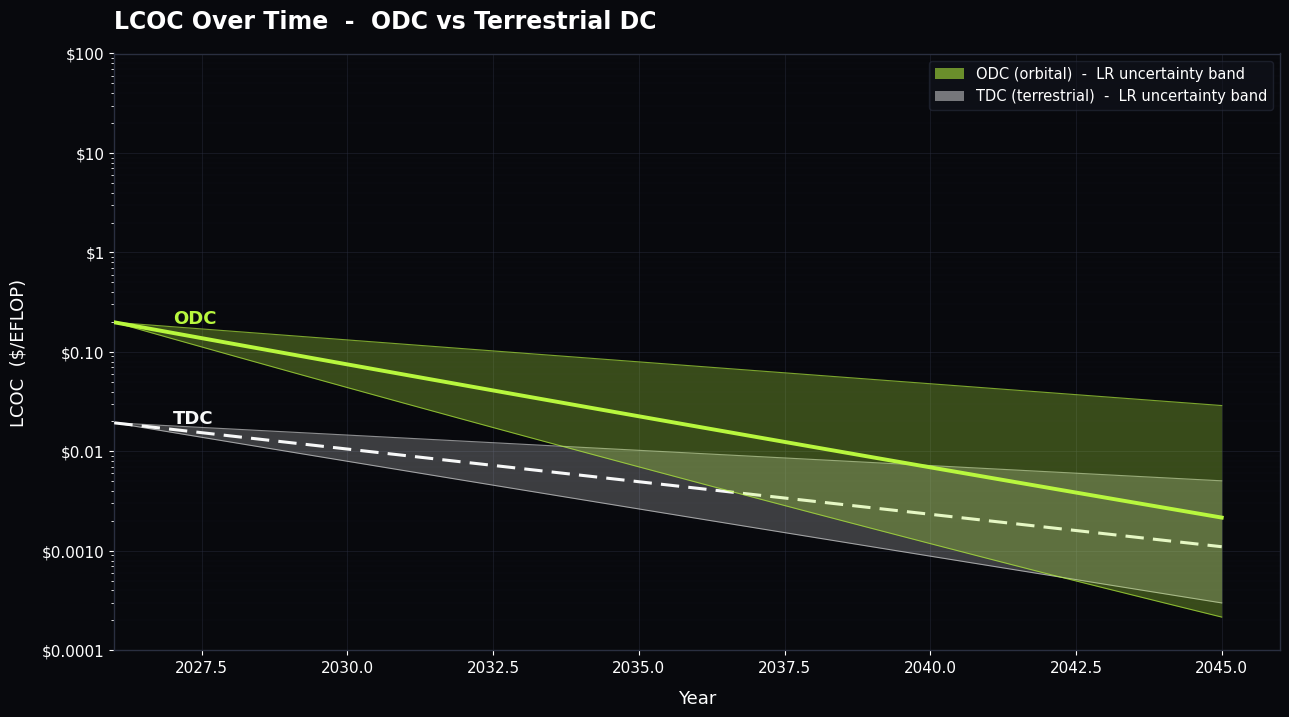

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7.5))

# TDC band
ax.fill_between(years_calendar, tdc_lo, tdc_hi, color=TDC_COLOR, alpha=0.22,
                zorder=2, linewidth=0)
ax.plot(years_calendar, tdc_hi, color=TDC_COLOR, linewidth=0.8, alpha=0.55, zorder=3)
ax.plot(years_calendar, tdc_lo, color=TDC_COLOR, linewidth=0.8, alpha=0.55, zorder=3)
ax.plot(years_calendar, tdc_nom, color=TDC_COLOR, linewidth=2.2,
        linestyle=(0,(6,3)), zorder=4)

# ODC band
ax.fill_between(years_calendar, odc_lo, odc_hi, color=ODC_COLOR, alpha=0.28,
                zorder=5, linewidth=0)
ax.plot(years_calendar, odc_hi, color=ODC_COLOR, linewidth=0.8, alpha=0.65, zorder=6)
ax.plot(years_calendar, odc_lo, color=ODC_COLOR, linewidth=0.8, alpha=0.65, zorder=6)
ax.plot(years_calendar, odc_nom, color=ODC_COLOR, linewidth=2.8, zorder=7)

# Crossover annotation (baseline-LR ODC = baseline-LR TDC)
diff = odc_nom - tdc_nom
crosses = np.where(np.diff(np.sign(diff)))[0]
for cx in crosses:
    cy = (odc_nom[cx] + tdc_nom[cx]) / 2
    ax.axvline(years_calendar[cx], color=WHITE, linewidth=0.7,
               linestyle=':', alpha=0.5, zorder=2)
    ax.annotate(f'Breakeven\n{years_calendar[cx]}',
                xy=(years_calendar[cx], cy),
                xytext=(years_calendar[cx]+1.5, cy*4.0),
                fontsize=10, color=WHITE, fontfamily=FONT, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=WHITE, alpha=0.55, lw=0.9))

# End-of-line labels
ax.text(2027, odc_nom[0]*1.1, 'ODC', color=ODC_COLOR, fontfamily=FONT,
        fontsize=13, fontweight='bold', va='center')
ax.text(2027, tdc_nom[0]*1.1, 'TDC', color=TDC_COLOR, fontfamily=FONT,
        fontsize=13, fontweight='bold', va='center')

handles = [
    mpatches.Patch(facecolor=ODC_COLOR, alpha=0.55,
                   label='ODC (orbital)  -  LR uncertainty band'),
    mpatches.Patch(facecolor=TDC_COLOR, alpha=0.45,
                   label='TDC (terrestrial)  -  LR uncertainty band'),
]
leg = ax.legend(handles=handles, loc='upper right', frameon=True,
                framealpha=0.55, edgecolor=GRID,
                facecolor='#12141e', fontsize=10.5,
                prop={'family': FONT, 'size': 10.5})
for t in leg.get_texts(): t.set_color(WHITE)

style_axes(ax, fig,
    title='LCOC Over Time  -  ODC vs Terrestrial DC',
#     subtitle='100 MW MEO  -  15-yr life  -  bands span pessimistic <-> optimistic learning rates  -  2026-2045',
    xlabel='Year',
    ylabel='LCOC  ($/EFLOP)',
    xlim=(2026, 2046),
    ylim=(0.0001, 100),
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 8b. Tornado sensitivity chart

Each row swings one variable up and down independently around the 2026 baseline and records the resulting LCOC. Rows are sorted by total swing magnitude — variables at the top dominate cost uncertainty. Green = cheaper-LCOC direction; red = more-expensive direction.

findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: F

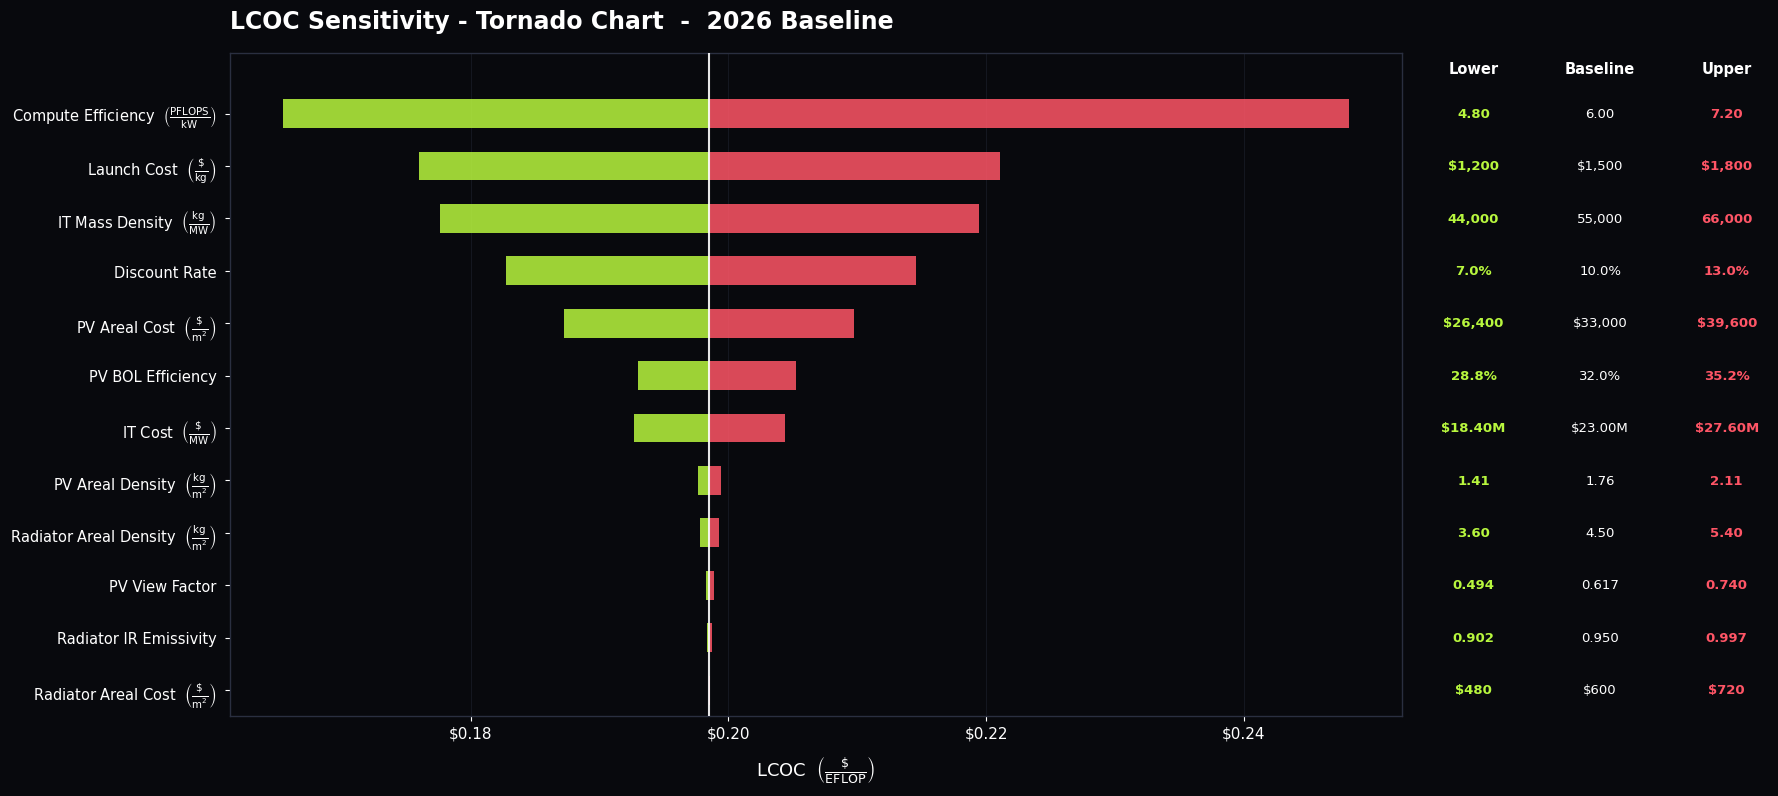

In [ ]:
# Parameters to vary, with +/- range
PARAMS_TO_VARY = [
    ('Launch Cost  ' + r'$\left(\frac{\$}{\mathrm{kg}}\right)$',
     'launch_cost_per_kg', 0.20),
    ('Compute Efficiency  ' + r'$\left(\frac{\mathrm{PFLOPS}}{\mathrm{kW}}\right)$',
     'gamma_PFLOPS_per_kW', 0.20),
    ('IT Cost  ' + r'$\left(\frac{\$}{\mathrm{MW}}\right)$',
     'it_cost_per_MW', 0.20),
    ('PV Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'pv_areal_cost', 0.20),
    ('IT Mass Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{MW}}\right)$',
     'it_mass_density', 0.20),
    ('PV Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'pv_areal_mass', 0.20),
    ('Radiator Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'rad_areal_cost', 0.20),
    ('Discount Rate', 'discount_rate', 0.30),
    ('PV BOL Efficiency', 'pv_eff_BOL', 0.10),
    ('Radiator IR Emissivity', 'eps_IR', 0.05),
    ('PV View Factor', 'F_PV', 0.20),
    ('Radiator Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'rad_areal_mass', 0.20),
]


def format_param_value(attr, value):
    """Pretty formatter for the Lower / Baseline / Upper value table."""
    if attr in ['discount_rate', 'pv_eff_BOL']:
        return f'{100 * value:.1f}%'
    if attr in ['eps_IR', 'alpha_solar_rad', 'F_PV', 'F_earth']:
        return f'{value:.3f}'
    if attr in ['launch_cost_per_kg', 'rad_areal_cost', 'pv_areal_cost']:
        return f'${value:,.0f}'
    if attr == 'it_cost_per_MW':
        return f'${value / 1e6:.2f}M'
    if attr in ['it_mass_density']:
        return f'{value:,.0f}'
    if attr in ['pv_areal_mass', 'rad_areal_mass']:
        return f'{value:.2f}'
    if attr == 'gamma_PFLOPS_per_kW':
        return f'{value:.2f}'
    return f'{value:,.3g}'


base_lcoc = calculate_lcoc(BASELINE)['lcoc']

bars = []
for label, attr, delta in PARAMS_TO_VARY:
    base_val = getattr(BASELINE, attr)
    low_param_val  = base_val * (1 - delta)
    high_param_val = base_val * (1 + delta)
    lcoc_hi = calculate_lcoc(replace(BASELINE, **{attr: high_param_val}))['lcoc']
    lcoc_lo = calculate_lcoc(replace(BASELINE, **{attr: low_param_val}))['lcoc']
    left   = min(lcoc_lo, lcoc_hi)
    right  = max(lcoc_lo, lcoc_hi)
    swing  = right - left
    bars.append((label, attr, left, right, swing,
                 low_param_val, base_val, high_param_val))

bars.sort(key=lambda x: x[4], reverse=True)

# -----------------------------------------------------------------------------
# Figure layout: main chart on left, value table on right
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(19, 8.5))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[7.0, 2.1],
                     left=0.17, right=0.98, top=0.88, bottom=0.10, wspace=0.02)
ax     = fig.add_subplot(gs[0, 0])
ax_tbl = fig.add_subplot(gs[0, 1])

bar_h = 0.55
for i, (label, attr, left_v, right_v, swing, low_val, mid_val, high_val) in enumerate(bars):
    ax.barh(i, left_v  - base_lcoc, left=base_lcoc, height=bar_h,
            color=ODC_COLOR, alpha=0.85, zorder=3)
    ax.barh(i, right_v - base_lcoc, left=base_lcoc, height=bar_h,
            color=ACCENT_R, alpha=0.85, zorder=3)

ax.axvline(base_lcoc, color=WHITE, linewidth=1.5, alpha=0.9, zorder=5)

style_axes(ax, fig,
    title='LCOC Sensitivity - Tornado Chart  -  2026 Baseline',
    xlabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
    y_log=False, y_dollar=False, x_dollar=True,
)
ax.set_yticks(range(len(bars)))
ax.set_yticklabels([b[0] for b in bars], fontfamily=FONT,
                   color=WHITE, fontsize=10.5)
ax.tick_params(axis='y', pad=6)
ax.grid(axis='y', alpha=0)
ax.grid(axis='x', color=GRID, alpha=0.45, linewidth=0.6)
ax.set_ylim(len(bars) - 0.5, -1.15)

# Right-side value table
ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(len(bars) - 0.5, -1.15)
ax_tbl.axis('off')

table_x_low, table_x_base, table_x_high = 0.16, 0.52, 0.88
header_y = -0.85

for x, label in [(table_x_low, 'Lower'),
                 (table_x_base, 'Baseline'),
                 (table_x_high, 'Upper')]:
    ax_tbl.text(x, header_y, label, ha='center', va='center',
                fontsize=10.5, color=WHITE, fontfamily=FONT, fontweight='bold')

for i, (label, attr, left_v, right_v, swing, low_val, mid_val, high_val) in enumerate(bars):
    ax_tbl.text(table_x_low,  i, format_param_value(attr, low_val),
                ha='center', va='center', fontsize=9.5,
                color=ODC_COLOR, fontfamily=FONT, fontweight='bold')
    ax_tbl.text(table_x_base, i, format_param_value(attr, mid_val),
                ha='center', va='center', fontsize=9.5,
                color=WHITE, fontfamily=FONT)
    ax_tbl.text(table_x_high, i, format_param_value(attr, high_val),
                ha='center', va='center', fontsize=9.5,
                color=ACCENT_R, fontfamily=FONT, fontweight='bold')

plt.show()

findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: F

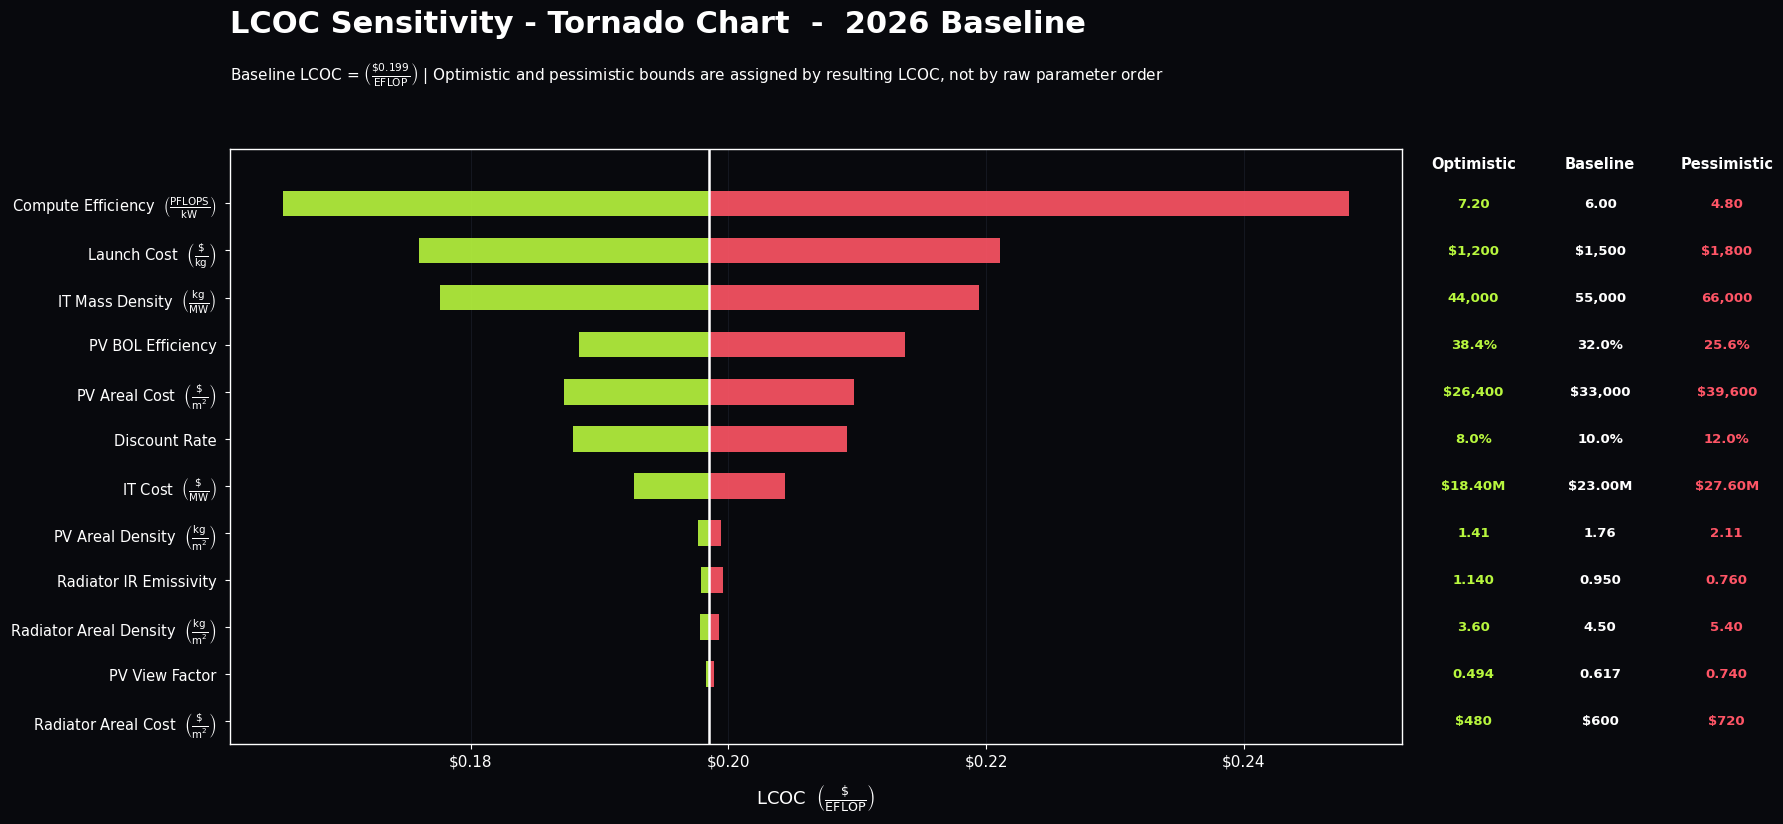

In [ ]:
# Parameters to vary, with +/- range
PARAMS_TO_VARY = [
    ('Launch Cost  ' + r'$\left(\frac{\$}{\mathrm{kg}}\right)$',
    'launch_cost_per_kg', 0.20),
    ('Compute Efficiency  ' + r'$\left(\frac{\mathrm{PFLOPS}}{\mathrm{kW}}\right)$',
    'gamma_PFLOPS_per_kW', 0.20),
    ('IT Cost  ' + r'$\left(\frac{\$}{\mathrm{MW}}\right)$',
    'it_cost_per_MW', 0.20),
    ('PV Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
    'pv_areal_cost', 0.20),
    ('IT Mass Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{MW}}\right)$',
    'it_mass_density', 0.20),
    ('PV Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
    'pv_areal_mass', 0.20),
    ('Radiator Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
    'rad_areal_cost', 0.20),
    ('Discount Rate', 'discount_rate', 0.2),
    ('PV BOL Efficiency', 'pv_eff_BOL', 0.20),
    ('Radiator IR Emissivity', 'eps_IR', 0.2),
    ('PV View Factor', 'F_PV', 0.20),
    ('Radiator Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
    'rad_areal_mass', 0.20),
]


def format_param_value(attr, value):
    """Pretty formatter for the Optimistic / Baseline / Pessimistic value table."""
    if attr in ['discount_rate', 'pv_eff_BOL']:
        return f'{100 * value:.1f}%'
    if attr in ['eps_IR', 'alpha_solar_rad', 'F_PV', 'F_earth']:
        return f'{value:.3f}'
    if attr in ['launch_cost_per_kg', 'rad_areal_cost', 'pv_areal_cost']:
        return f'${value:,.0f}'
    if attr == 'it_cost_per_MW':
        return f'${value / 1e6:.2f}M'
    if attr in ['it_mass_density']:
        return f'{value:,.0f}'
    if attr in ['pv_areal_mass', 'rad_areal_mass']:
        return f'{value:.2f}'
    if attr == 'gamma_PFLOPS_per_kW':
        return f'{value:.2f}'
    return f'{value:,.3g}'


base_lcoc = calculate_lcoc(BASELINE)['lcoc']

bars = []

for label, attr, delta in PARAMS_TO_VARY:
    base_val = getattr(BASELINE, attr)

    low_param_val = base_val * (1 - delta)
    high_param_val = base_val * (1 + delta)

    lcoc_low_param = calculate_lcoc(
        replace(BASELINE, **{attr: low_param_val})
    )['lcoc']

    lcoc_high_param = calculate_lcoc(
        replace(BASELINE, **{attr: high_param_val})
    )['lcoc']

    # ---------------------------------------------------------
    # Key fix:
    # Sort the low/high parameter cases by resulting LCOC.
    # The lower-LCOC case is optimistic.
    # The higher-LCOC case is pessimistic.
    # This correctly flips variables like compute efficiency.
    # ---------------------------------------------------------
    cases = [
        {
            'param_value': low_param_val,
            'lcoc': lcoc_low_param,
            'raw_side': 'low',
        },
        {
            'param_value': high_param_val,
            'lcoc': lcoc_high_param,
            'raw_side': 'high',
        },
    ]

    cases_sorted = sorted(cases, key=lambda d: d['lcoc'])

    optimistic_case = cases_sorted[0]
    pessimistic_case = cases_sorted[-1]

    optimistic_val = optimistic_case['param_value']
    pessimistic_val = pessimistic_case['param_value']

    optimistic_lcoc = optimistic_case['lcoc']
    pessimistic_lcoc = pessimistic_case['lcoc']

    swing = pessimistic_lcoc - optimistic_lcoc

    bars.append((
        label,
        attr,
        optimistic_lcoc,
        base_lcoc,
        pessimistic_lcoc,
        swing,
        optimistic_val,
        base_val,
        pessimistic_val,
    ))

# Sort by total LCOC swing magnitude
bars.sort(key=lambda x: x[5], reverse=True)


# -----------------------------------------------------------------------------
# Figure layout: main chart on left, value table on right
# -----------------------------------------------------------------------------

fig = plt.figure(figsize=(19, 8.5))

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[7.0, 2.1],
    left=0.17,
    right=0.98,
    top=0.80,
    bottom=0.10,
    wspace=0.02,
)

ax = fig.add_subplot(gs[0, 0])
ax_tbl = fig.add_subplot(gs[0, 1])


# -----------------------------------------------------------------------------
# Tornado bars
# -----------------------------------------------------------------------------

bar_h = 0.55

for i, (
    label,
    attr,
    optimistic_lcoc,
    baseline_lcoc,
    pessimistic_lcoc,
    swing,
    optimistic_val,
    baseline_val,
    pessimistic_val,
) in enumerate(bars):

    # Optimistic case: lower LCOC side
    ax.barh(
        i,
        optimistic_lcoc - base_lcoc,
        left=base_lcoc,
        height=bar_h,
        color=ODC_COLOR,
        alpha=0.90,
        zorder=3,
    )

    # Pessimistic case: higher LCOC side
    ax.barh(
        i,
        pessimistic_lcoc - base_lcoc,
        left=base_lcoc,
        height=bar_h,
        color=ACCENT_R,
        alpha=0.90,
        zorder=3,
    )


# Baseline vertical line
ax.axvline(
    base_lcoc,
    color="#FFFFFF",
    linewidth=1.8,
    alpha=1.0,
    zorder=5,
)


# Use style_axes for axis styling, but draw title/subtitle manually
style_axes(
    ax,
    fig,
    title='',
    subtitle='',
    xlabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
    y_log=False,
    y_dollar=False,
    x_dollar=True,
)


# Manual title and subtitle with better spacing
fig.text(
    0.17,
    0.965,
    'LCOC Sensitivity - Tornado Chart  -  2026 Baseline',
    ha='left',
    va='top',
    fontsize=22,
    color="#FFFFFF",
    fontfamily=FONT,
    fontweight='bold',
)

fig.text(
    0.17,
    0.905,
    (
        fr'Baseline LCOC = $\left(\frac{{\${base_lcoc:.3f}}}{{\mathrm{{EFLOP}}}}\right)$'
        ' | Optimistic and pessimistic bounds are assigned by resulting LCOC, not by raw parameter order'
    ),
    ha='left',
    va='top',
    fontsize=11,
    color="#FFFFFF",
    alpha=1.0,
    fontfamily=FONT,
)


# Reapply categorical y-tick labels after style_axes
ax.set_yticks(range(len(bars)))

ax.set_yticklabels(
    [b[0] for b in bars],
    fontfamily=FONT,
    color="#FFFFFF",
    fontsize=10.5,
)

ax.tick_params(axis='x', colors="#FFFFFF")
ax.tick_params(axis='y', colors="#FFFFFF", pad=6)

for spine in ax.spines.values():
    spine.set_color("#FFFFFF")
    spine.set_alpha(1.0)

ax.grid(axis='y', alpha=0)
ax.grid(axis='x', color=GRID, alpha=0.45, linewidth=0.6)

# Largest swing at the top, with room for table header
ax.set_ylim(len(bars) - 0.5, -1.15)


# -----------------------------------------------------------------------------
# Right-side value table
# -----------------------------------------------------------------------------

ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(len(bars) - 0.5, -1.15)
ax_tbl.axis('off')

table_x_optimistic = 0.16
table_x_base = 0.52
table_x_pessimistic = 0.88

header_y = -0.85

for x, header in [
    (table_x_optimistic, 'Optimistic'),
    (table_x_base, 'Baseline'),
    (table_x_pessimistic, 'Pessimistic'),
]:
    ax_tbl.text(
        x,
        header_y,
        header,
        ha='center',
        va='center',
        fontsize=10.5,
        color="#FFFFFF",
        fontfamily=FONT,
        fontweight='bold',
    )


for i, (
    label,
    attr,
    optimistic_lcoc,
    baseline_lcoc,
    pessimistic_lcoc,
    swing,
    optimistic_val,
    baseline_val,
    pessimistic_val,
) in enumerate(bars):

    ax_tbl.text(
        table_x_optimistic,
        i,
        format_param_value(attr, optimistic_val),
        ha='center',
        va='center',
        fontsize=9.5,
        color=ODC_COLOR,
        fontfamily=FONT,
        fontweight='bold',
    )

    ax_tbl.text(
        table_x_base,
        i,
        format_param_value(attr, baseline_val),
        ha='center',
        va='center',
        fontsize=9.5,
        color="#FFFFFF",
        fontfamily=FONT,
        fontweight='bold',
    )

    ax_tbl.text(
        table_x_pessimistic,
        i,
        format_param_value(attr, pessimistic_val),
        ha='center',
        va='center',
        fontsize=9.5,
        color=ACCENT_R,
        fontfamily=FONT,
        fontweight='bold',
    )


plt.show()

### 8c. LCOC vs launch cost sweep

How sensitive is LCOC to launch cost? Three solid/dashed curves at 2026, 2035, 2045 (under baseline learning rates) — each curve sweeps launch cost from \$50 to \$5000/kg while holding everything else at that year's evolved values. Markers show where the baseline launch-cost trajectory lands each year. Horizontal lines = TDC reference at the same year.

findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: F

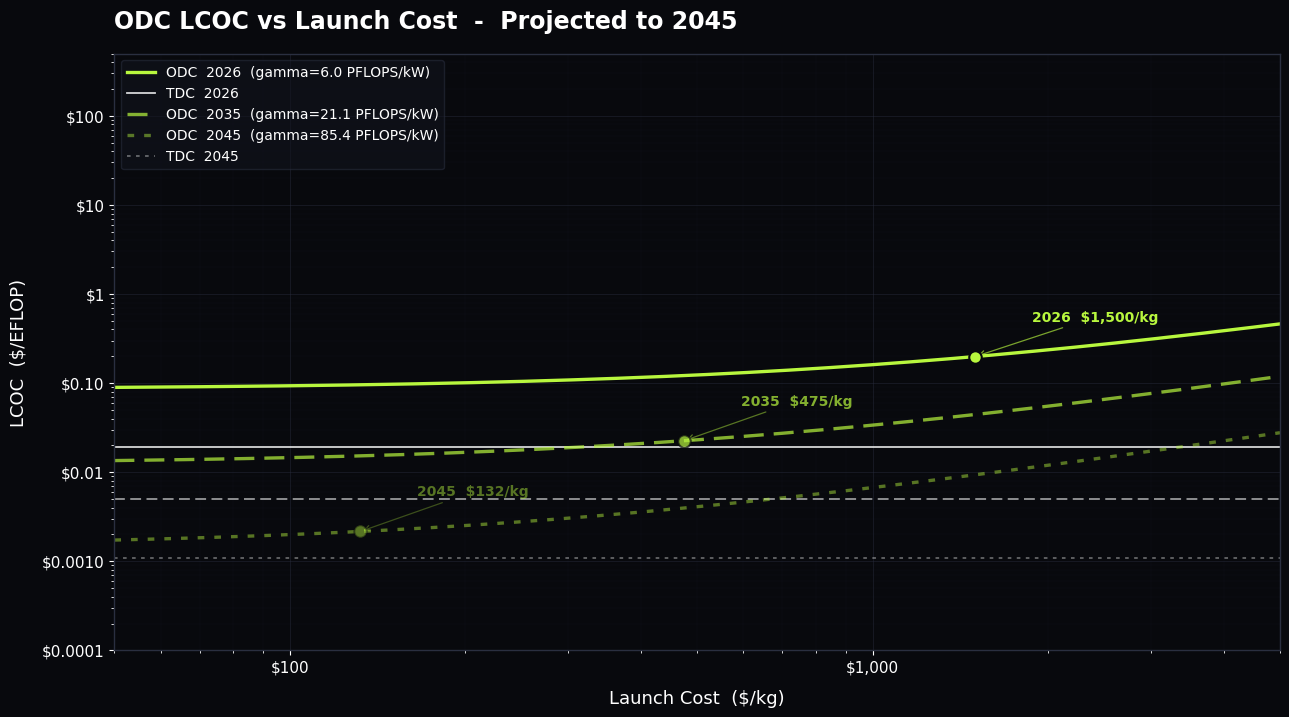

In [ ]:
launch_costs  = np.logspace(np.log10(50), np.log10(5000), 200)
years_to_show = {'2026': 0, '2035': 9, '2045': 19}
line_alphas   = {'2026': 1.00, '2035': 0.70, '2045': 0.45}
line_styles   = {'2026': 'solid', '2035': (0,(6,3)), '2045': (0,(2,3))}

fig, ax = plt.subplots(figsize=(13, 7.5))

for yr_label, yo in years_to_show.items():
    ev_base = evolve_scenario(BASELINE, yo, LR_BASELINE)
    tdc_yr  = terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, LR_BASELINE)
    lcocs = np.array([
        calculate_lcoc(replace(ev_base, launch_cost_per_kg=lc))['lcoc']
        for lc in launch_costs
    ])
    a  = line_alphas[yr_label]
    ls = line_styles[yr_label]

    ax.plot(launch_costs, lcocs, color=ODC_COLOR, linewidth=2.4,
            linestyle=ls, alpha=a,
            label=f'ODC  {yr_label}  (gamma={ev_base.gamma_PFLOPS_per_kW:.1f} PFLOPS/kW)')

    nom_lc   = BASELINE.launch_cost_per_kg * (1 - LR_BASELINE.launch)**yo
    nom_lcoc = calculate_lcoc(replace(ev_base, launch_cost_per_kg=nom_lc))['lcoc']
    ax.plot(nom_lc, nom_lcoc, 'o', color=ODC_COLOR, markersize=9,
            alpha=a, zorder=10, markeredgecolor=BG, markeredgewidth=1.5)
    ax.annotate(f'{yr_label}  ${nom_lc:,.0f}/kg',
                xy=(nom_lc, nom_lcoc),
                xytext=(nom_lc * 1.25, nom_lcoc * 2.5),
                fontsize=10, color=ODC_COLOR, fontfamily=FONT,
                alpha=a, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=ODC_COLOR,
                                alpha=a*0.65, lw=0.9))

    ax.axhline(tdc_yr, color=TDC_COLOR, linewidth=1.3,
               linestyle=ls, alpha=a*0.85,
               label=f'TDC  {yr_label}' if yr_label in ('2026', '2045') else None)

leg = ax.legend(loc='upper left', frameon=True, framealpha=0.55,
                edgecolor=GRID, facecolor='#12141e',
                prop={'family': FONT, 'size': 10})
for t in leg.get_texts(): t.set_color(WHITE)

style_axes(ax, fig,
    title='ODC LCOC vs Launch Cost  -  Projected to 2045',
    # subtitle='Dashed = 2035 & 2045 projection at baseline learning rates  -  Circles = baseline launch cost that year  -  TDC reference lines',
    xlabel='Launch Cost  ($/kg)',
    ylabel='LCOC  ($/EFLOP)',
    x_log=True, y_log=True,
    xlim=(50, 5000), ylim=(0.0001, 500),
    x_dollar=True, y_dollar=True,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 9. Summary

In [ ]:
print('=' * 96)
print('SUMMARY: Orbital vs Terrestrial DC LCOC (2026-2045)')
print('=' * 96)
print(f'\nBaseline ODC parameters (locked initial values, 2026):')
print(f'  gamma           = {BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW')
print(f'  Launch          = ${BASELINE.launch_cost_per_kg:,.0f}/kg')
print(f'  PV eta_BOL      = {BASELINE.pv_eff_BOL}')
print(f'  PV areal cost   = ${BASELINE.pv_areal_cost:,.0f}/m^2')
print(f'  Rad areal cost  = ${BASELINE.rad_areal_cost:,.0f}/m^2')
print(f'  IT cost         = ${BASELINE.it_cost_per_MW/1e6:.1f}M/MW')
print(f'  alpha_solar     = {BASELINE.alpha_solar_rad}')
print(f'  alpha_IR        = {BASELINE.eps_IR}')
print(f'\nLearning-rate scenarios drive the uncertainty band on plots.')
print()

print(f'{"Year":>6s}  |   {"ODC range $/EFLOP":>32s}     {"TDC range $/EFLOP":>32s}  |  ratio')
print(f'{"":>6s}  |   {"(pes / base / opt)":>32s}     {"(pes / base / opt)":>32s}  |  (base)')
print('-' * 96)
for label, idx in [('2026', 0), ('2030', 4), ('2035', 9), ('2040', 14), ('2045', 19)]:
    odc_range = f'${odc_lo[idx]:.4f} / ${odc_nom[idx]:.4f} / ${odc_hi[idx]:.4f}'
    tdc_range = f'${tdc_lo[idx]:.4f} / ${tdc_nom[idx]:.4f} / ${tdc_hi[idx]:.4f}'
    print(f'{label:>6s}  |   {odc_range:>32s}     {tdc_range:>32s}  |  {odc_nom[idx]/tdc_nom[idx]:.2f}x')

print()
print('Cost breakdown for 2026 baseline ODC:')
for k, v in baseline_result['breakdown'].items():
    print(f'  {k:10s} ${v:.4f}/EFLOP   ({v/baseline_result["lcoc"]*100:5.1f}%)')

print()
print('Key takeaways:')
print('  - Initial parameter values are locked; only the learning rate varies.')
print('  - Launch cost decline drives the ODC trajectory; under baseline LR, launch falls')
print('    below ~$200/kg by 2045, narrowing the gap to TDC substantially.')
print('  - gamma improvement applies to both ODC and TDC equally and shifts both curves')
print('    down in parallel - it does not by itself close the ODC/TDC gap.')
print('  - PV areal cost ($33,000/m^2) and IT cost ($23M/MW) are now the second-tier')
print('    sensitivities behind launch.  See the tornado chart for confirmation.')

SUMMARY: Orbital vs Terrestrial DC LCOC (2026-2045)

Baseline ODC parameters (locked initial values, 2026):
  gamma           = 6.0 PFLOPS/kW
  Launch          = $1,500/kg
  PV eta_BOL      = 0.32
  PV areal cost   = $33,000/m^2
  Rad areal cost  = $600/m^2
  IT cost         = $23.0M/MW
  alpha_solar     = 0.05
  alpha_IR        = 0.95

Learning-rate scenarios drive the uncertainty band on plots.

  Year  |                  ODC range $/EFLOP                    TDC range $/EFLOP  |  ratio
        |                 (pes / base / opt)                   (pes / base / opt)  |  (base)
------------------------------------------------------------------------------------------------
  2026  |        $0.1985 / $0.1985 / $0.1985          $0.0194 / $0.0194 / $0.0194  |  10.25x
  2030  |        $0.1321 / $0.0749 / $0.0438          $0.0146 / $0.0106 / $0.0080  |  7.09x
  2035  |        $0.0795 / $0.0225 / $0.0070          $0.0103 / $0.0050 / $0.0026  |  4.55x
  2040  |        $0.0479 / $0.0069 / $0.

# Carbon Impact

In [ ]:
"""
TDC (Terrestrial Data Center) carbon model
===========================================
Capacity-driven cradle-to-grave embodied + operational carbon for an AI data center.

Method follows:
  * Alissa et al. (2025), Nature 641:331-338  -- facility LCA: per-component factors,
    annualized by lifetime, operational = IT_MW x PUE x load x 8760 x grid_intensity.
  * Falk et al. (2025), arXiv:2509.00093      -- teardown primary-data GPU embodied LCA.
  * NVIDIA HGX B200 PCF (Jul 2025)            -- current-gen accelerator embodied (cradle-to-gate).
Facility per-m2 factors from Alissa et al. / CIBSE TM65 / CLF. Schneider WP99 NOT used.
"""

from dataclasses import dataclass, asdict
import csv
import math

# ----------------------------------------------------------------------------
# Emission factors (edit here; sources in comments)
# ----------------------------------------------------------------------------
# --- IT, current generation (NVIDIA HGX B200 PCF, Jul 2025; cradle-to-gate) ---
GPU_BASEBOARD_KGCO2E = 2274.0   # per 8-GPU HGX B200 baseboard
GPUS_PER_BASEBOARD   = 8
HOST_SERVER_KGCO2E   = 1300.0   # per 2-socket host node, manufacturing (Boavizta/Dell R740)

# --- Facility, per m2 of floor (Alissa et al. / CIBSE TM65 / CLF) ---
CORE_SHELL_KGCO2E_M2 = 650.0    # midpoint of 500-800 (concrete ~85%)
MEP_KGCO2E_M2        = 400.0    # midpoint of 300-500 (electrical + mechanical incl. cooling)

# --- Falk et al. A100 reference (older gen; cross-check only, not used in totals) ---
A100_TOTAL_KGCO2E    = 127.6    # cradle-to-grave teardown; chip 104.3, PCB 8.16, heatsink 4.85


@dataclass
class Config:
    it_capacity_mw: float = 100.0   # critical IT load
    mission_years: int    = 15
    pue: float            = 1.12
    load_factor: float    = 1.0     # utilization k
    grid_intensity: float = 0.40    # tCO2e/MWh (== kgCO2e/kWh). EPA eGRID US ~0.37
    grid_decarb: float    = 0.0     # annual fractional decline in grid intensity
    it_refresh_years: int = 4       # GPU/server refresh cadence
    node_power_kw: float  = 10.4    # 8x ~1 kW B200 + host overhead
    power_density_kw_m2: float = 2.0  # facility kW IT per m2 (denser -> less building/MW)
    mep_refresh_years: int = 0      # 0 = MEP installed once (life >= mission); else partial refresh
    mep_refresh_frac: float = 0.3   # fraction of MEP embodied replaced at each MEP refresh


def subsystem_quantities(cfg: Config) -> dict:
    """How much of each subsystem the chosen capacity needs."""
    nodes = cfg.it_capacity_mw * 1000.0 / cfg.node_power_kw
    return {
        "compute_nodes": nodes,
        "gpus": nodes * GPUS_PER_BASEBOARD,
        "floor_area_m2": cfg.it_capacity_mw * 1000.0 / cfg.power_density_kw_m2,
        "it_generations": math.ceil(cfg.mission_years / cfg.it_refresh_years),
    }


def embodied_breakdown(cfg: Config) -> dict:
    """One-generation embodied carbon per subsystem (tCO2e)."""
    q = subsystem_quantities(cfg)
    it_per_gen = q["compute_nodes"] * (GPU_BASEBOARD_KGCO2E + HOST_SERVER_KGCO2E) / 1000.0
    return {
        "IT (per generation)": it_per_gen,
        "Core & shell": q["floor_area_m2"] * CORE_SHELL_KGCO2E_M2 / 1000.0,
        "MEP (electrical + cooling)": q["floor_area_m2"] * MEP_KGCO2E_M2 / 1000.0,
    }


def annual_profile(cfg: Config):
    """Year-by-year embodied (with refresh spikes) and operational carbon (tCO2e)."""
    eb = embodied_breakdown(cfg)
    years = list(range(cfg.mission_years))
    embodied_spikes = [0.0] * cfg.mission_years
    operational     = [0.0] * cfg.mission_years

    # Year 0: building shell + MEP + first IT generation
    embodied_spikes[0] += eb["Core & shell"] + eb["MEP (electrical + cooling)"]
    # IT refresh spikes (installs at 0, refresh_interval, 2*refresh_interval, ...)
    for gen in range(subsystem_quantities(cfg)["it_generations"]):
        yr = gen * cfg.it_refresh_years
        if yr < cfg.mission_years:
            embodied_spikes[yr] += eb["IT (per generation)"]
    # Optional MEP partial refresh
    if cfg.mep_refresh_years and cfg.mep_refresh_years > 0:
        yr = cfg.mep_refresh_years
        while yr < cfg.mission_years:
            embodied_spikes[yr] += eb["MEP (electrical + cooling)"] * cfg.mep_refresh_frac
            yr += cfg.mep_refresh_years

    # Operational, with optional grid decarbonization
    annual_mwh = cfg.it_capacity_mw * cfg.pue * cfg.load_factor * 8760.0
    for y in years:
        gi = cfg.grid_intensity * (1.0 - cfg.grid_decarb) ** y
        operational[y] = annual_mwh * gi

    cum_emb = [sum(embodied_spikes[:y + 1]) for y in years]
    cum_op  = [sum(operational[:y + 1]) for y in years]
    return years, embodied_spikes, operational, cum_emb, cum_op


def summarize(cfg: Config) -> dict:
    q = subsystem_quantities(cfg)
    eb = embodied_breakdown(cfg)
    years, spikes, op, cum_emb, cum_op = annual_profile(cfg)
    total_embodied = cum_emb[-1]
    total_op = cum_op[-1]
    total = total_embodied + total_op
    return {
        "quantities": q,
        "embodied_per_subsystem_total": {
            "IT (all generations)": eb["IT (per generation)"] * q["it_generations"],
            "Core & shell": eb["Core & shell"],
            "MEP (electrical + cooling)": eb["MEP (electrical + cooling)"],
        },
        "total_embodied_tco2e": total_embodied,
        "total_operational_tco2e": total_op,
        "total_lifecycle_tco2e": total,
        "embodied_share": total_embodied / total if total else 0.0,
        "operational_share": total_op / total if total else 0.0,
        "lifecycle_per_mw": total / cfg.it_capacity_mw,
        "profile": {"years": years, "embodied_spikes": spikes, "operational": op,
                    "cum_embodied": cum_emb, "cum_operational": cum_op},
    }


def print_report(cfg: Config, s: dict):
    q = s["quantities"]
    print("=" * 64)
    print(f"TDC CARBON MODEL  -  {cfg.it_capacity_mw:g} MW IT, {cfg.mission_years} yr mission")
    print("=" * 64)
    print("\nSubsystem sizing")
    print(f"  Compute nodes        : {q['compute_nodes']:>12,.0f}")
    print(f"  GPUs                 : {q['gpus']:>12,.0f}")
    print(f"  Floor area (m2)      : {q['floor_area_m2']:>12,.0f}")
    print(f"  IT generations       : {q['it_generations']:>12d}")
    print("\nEmbodied carbon (tCO2e, mission total)")
    for k, v in s["embodied_per_subsystem_total"].items():
        print(f"  {k:<28}: {v:>12,.0f}")
    print(f"  {'TOTAL EMBODIED':<28}: {s['total_embodied_tco2e']:>12,.0f}")
    print("\nOperational carbon (tCO2e)")
    print(f"  {'TOTAL OPERATIONAL':<28}: {s['total_operational_tco2e']:>12,.0f}")
    print("\nLifecycle")
    print(f"  Total lifecycle      : {s['total_lifecycle_tco2e']:>12,.0f} tCO2e")
    print(f"  Embodied share       : {s['embodied_share']:>12.1%}")
    print(f"  Operational share    : {s['operational_share']:>12.1%}")
    print(f"  Per MW               : {s['lifecycle_per_mw']:>12,.0f} tCO2e/MW")
    print("=" * 64)


def make_plot(cfg: Config, s: dict):
    import matplotlib.pyplot as plt
    
    p = s["profile"]
    yrs = p["years"]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

    # Top: embodied detail
    ax1.bar(yrs, p["embodied_spikes"], width=0.55, color="#C0504D",
            label="Embodied spikes (build + refreshes)")
    ax1.plot(yrs, p["cum_embodied"], "-o", color="#1F3864", ms=4, label="Cumulative embodied")
    ax1.set_ylabel("Embodied carbon (tCO2e)")
    ax1.set_title(f"TDC embodied carbon - {cfg.it_capacity_mw:g} MW "
                  f"(IT refresh every {cfg.it_refresh_years} yr)")
    ax1.legend(loc="upper left", frameon=False)
    ax1.grid(axis="y", alpha=0.25)

    # Bottom: embodied vs operational dominance
    ax2.plot(yrs, p["cum_embodied"], "-o", color="#1F3864", ms=4, label="Cumulative embodied")
    ax2.plot(yrs, p["cum_operational"], "-s", color="#2E7D32", ms=4, label="Cumulative operational")
    ax2.set_xlabel("Mission year")
    ax2.set_ylabel("Carbon (tCO2e)")
    ax2.set_title(f"Lifecycle: operational {s['operational_share']:.0%} vs "
                  f"embodied {s['embodied_share']:.0%} (grid {cfg.grid_intensity} tCO2e/MWh)")
    ax2.legend(loc="upper left", frameon=False)
    ax2.grid(axis="y", alpha=0.25)

    fig.tight_layout()
    plt.show()  # Directly interactive without saving any files


In [ ]:
cfg = Config()
s = summarize(cfg)

# Direct terminal print + interactive popup window
print_report(cfg, s)
make_plot(cfg, s)